In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/processed/cleaned_accident_data.csv")

In [3]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,is_peak_hour,festival,risk_score,datetime,year,month,day,weekday,time_of_day,season
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,05:00:00,5,Sunday,1,...,0,Unknown,0.85,2023-10-22 05:00:00,2023,10,22,6,Morning,Post-Monsoon
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,04:00:00,4,Sunday,1,...,0,Unknown,0.10,2023-05-21 04:00:00,2023,5,21,6,Night,Summer
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00:00,13,Wednesday,0,...,0,Unknown,0.45,2024-07-10 13:00:00,2024,7,10,2,Afternoon,Monsoon
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00:00,11,Sunday,1,...,0,Unknown,0.65,2025-03-30 11:00:00,2025,3,30,6,Morning,Summer
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00:00,16,Thursday,0,...,0,Unknown,0.10,2024-01-25 16:00:00,2024,1,25,3,Afternoon,Winter


In [4]:
df.shape

(20000, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [6]:
df.describe()

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score,year,month,day,weekday
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585,2023.170600,6.15475,15.679900,2.990750
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130,0.962622,3.50825,8.809615,2.011931
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000,2022.000000,1.00000,1.000000,0.000000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000,2022.000000,3.00000,8.000000,1.000000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000,2023.000000,6.00000,16.000000,3.000000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000,2024.000000,9.00000,23.000000,5.000000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000,2025.000000,12.00000,31.000000,6.000000


In [8]:
top_cities = df["city"].value_counts().head(10)
top_cities

city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: count, dtype: int64

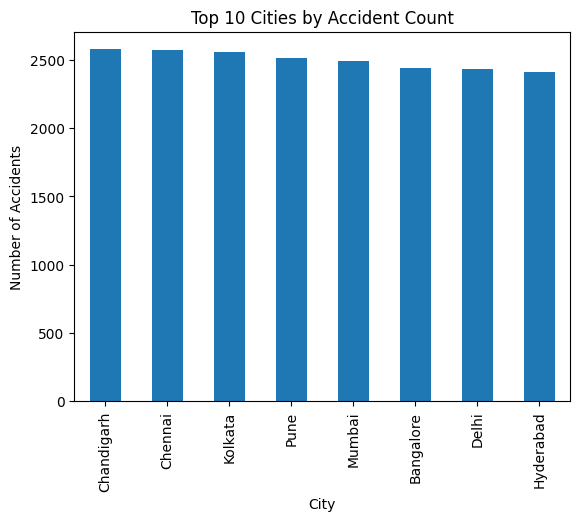

In [9]:
plt.figure()
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Accident Count")
plt.xlabel("City")
plt.ylabel("Number of Accidents")
plt.show()

In [12]:
df["risk_score"].value_counts()

risk_score
0.45    6421
0.10    3149
0.65    2740
0.25    2111
0.30    1664
0.80    1508
0.60    1304
0.85     298
0.40     269
1.00     227
0.50     212
0.55      41
0.75      19
0.20      12
0.90      11
0.35       7
0.70       6
0.95       1
Name: count, dtype: int64

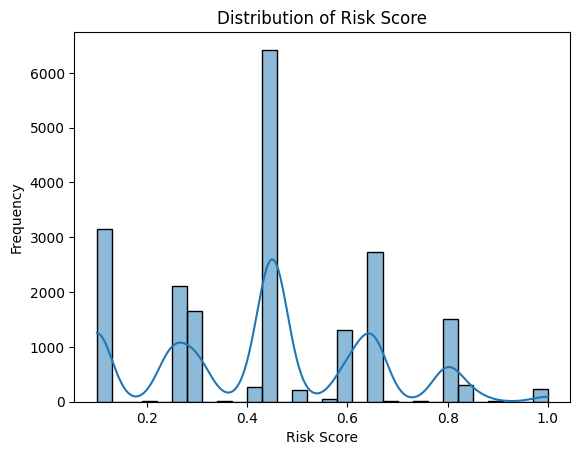

In [13]:
plt.figure()
sns.histplot(df["risk_score"], bins=30, kde=True)
plt.title("Distribution of Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

In [24]:
q1 = df["risk_score"].quantile(0.33)
q2 = df["risk_score"].quantile(0.66)

def risk_level(score):
    if score <= q1:
        return "Low"
    elif score <= q2:
        return "Medium"
    else:
        return "High"

df["risk_level"] = df["risk_score"].apply(risk_level)

In [26]:
df["risk_level"].value_counts()

risk_level
Low       6936
Medium    6697
High      6367
Name: count, dtype: int64

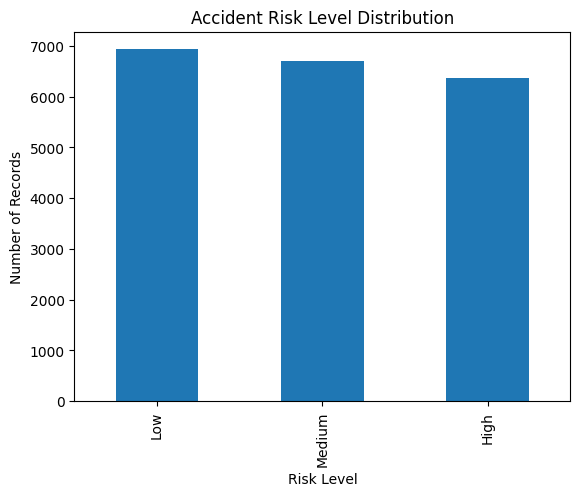

In [28]:
plt.figure()
df["risk_level"].value_counts().plot(kind="bar")
plt.title("Accident Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.show()

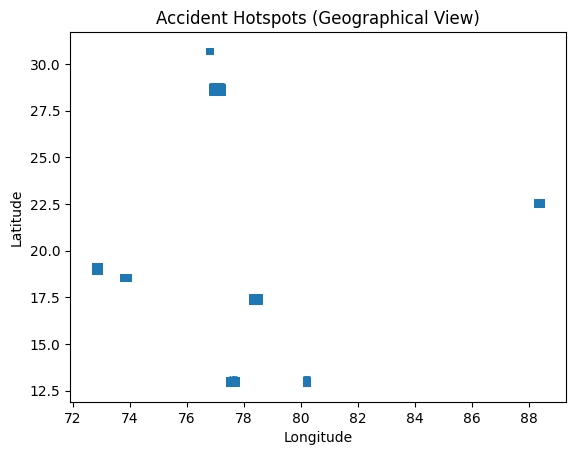

In [18]:
plt.figure()
plt.scatter(df["longitude"], df["latitude"], s=1)
plt.title("Accident Hotspots (Geographical View)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [19]:
df.groupby("city")["risk_score"].mean().sort_values(ascending=False).head(10)

city
Chandigarh    0.441618
Bangalore     0.440217
Hyderabad     0.439456
Chennai       0.437573
Delhi         0.437115
Pune          0.435836
Kolkata       0.434584
Mumbai        0.434350
Name: risk_score, dtype: float64

In [20]:
df["hour"].value_counts().sort_index()

hour
0     840
1     859
2     888
3     824
4     805
5     827
6     856
7     786
8     849
9     786
10    789
11    841
12    866
13    878
14    838
15    811
16    787
17    861
18    823
19    840
20    838
21    830
22    853
23    825
Name: count, dtype: int64

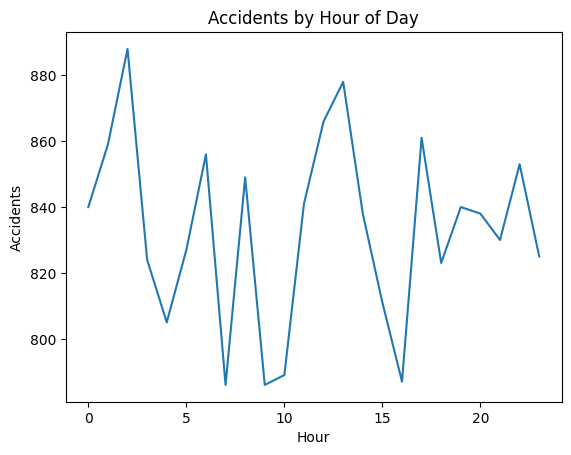

In [21]:
plt.figure()
df["hour"].value_counts().sort_index().plot()
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Accidents")
plt.show()

In [22]:
df["risk_score"].describe()

count    20000.000000
mean         0.437585
std          0.218130
min          0.100000
25%          0.250000
50%          0.450000
75%          0.600000
max          1.000000
Name: risk_score, dtype: float64